1. we will work to construct our own graph neural network using PyTorch Geometric (PyG)
2. apply that model on two Open Graph Benchmark (OGB) datasets.
3. These two datasets will be used to benchmark your model's performance on two different graph-based tasks: 
    1) node property prediction, predicting properties of single nodes and 
    2) graph property prediction, predicting properties of entire graphs or subgraphs.

OGB is a collection of realistic, large-scale, and diverse benchmark datasets for machine learning on graphs. The ogb package not only provides data loaders for each dataset but also model evaluators.

1. learn how PyTorch Geometric stores graphs as PyTorch tensors.
2. we will load and inspect one of the Open Graph Benchmark (OGB) datasets by using the ogb package.
3. we will build our own graph neural network using PyTorch Geometric. We will then train and evaluate our model on the OGB node property prediction and graph property prediction tasks.

In [1]:
import torch
import os
print("PyTorch has version {}".format(torch.__version__))

PyTorch has version 2.8.0+cu129


# Open Graph Benchmark (OGB)

The Open Graph Benchmark (OGB) is a collection of realistic, large-scale, and diverse benchmark datasets for machine learning on graphs. Its datasets are automatically downloaded, processed, and split using the OGB Data Loader. The model performance can then be evaluated by using the OGB Evaluator in a unified manner.

# Dataset and Data

OGB also supports PyG dataset and data classes. Here we take a look on the ogbn-arxiv dataset.

In [2]:
import torch_geometric.transforms as T
import torch_geometric
from ogb.nodeproppred import PygNodePropPredDataset

# Tell PyTorch it's safe to load PyG data objects
torch.serialization.add_safe_globals([
    torch_geometric.data.Dataset,
    torch_geometric.data.storage.GlobalStorage,
    torch_geometric.data.data.DataEdgeAttr,
    torch_geometric.data.Data,
    torch_geometric.data.data.DataTensorAttr
])

dataset_name = 'ogbn-arxiv'
# Load the dataset and transform it to sparse tensor
# No longer has the edge_index and it has adj_t for 1.16 million edges
dataset = PygNodePropPredDataset(name=dataset_name,
                                transform=T.ToSparseTensor())
print('The {} dataset has {} graph'.format(dataset_name, len(dataset)))

# Extract the graph
data = dataset[0]
print(data)

/home/hice1/pmaji3/scratch/gnn02/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/hice1/pmaji3/scratch/gnn02/lib/python3.12/site-packages/outdated/__init__.py:36: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import parse_version


The ogbn-arxiv dataset has 1 graph
Data(num_nodes=169343, x=[169343, 128], node_year=[169343, 1], y=[169343, 1], adj_t=[169343, 169343, nnz=1166243])


Question 4: How many features are in the ogbn-arxiv graph? (5 points)

In [3]:
def graph_num_features(data):
  # TODO: Implement a function that takes a PyG data object,
  # and returns the number of features in the graph (as an integer).

  num_features = 0

  ############# Your code here ############
  ## (~1 line of code)
  num_features = data.num_features
  #########################################

  return num_features

num_features = graph_num_features(data)
print('The graph has {} features'.format(num_features))

The graph has 128 features


# 1. GNN: Node Property Prediction
In this section we will build our first graph neural network using PyTorch Geometric. Then we will apply it to the task of node property prediction (node classification).

Specifically, we will use GCN as the foundation for your graph neural network (Kipf et al. (2017)). To do so, we will work with PyG's built-in GCNConv layer.

In [4]:
import torch
import pandas as pd
import torch.nn.functional as F
print(torch.__version__)

# The PyG built-in GCNConv
from torch_geometric.nn import GCNConv

import torch_geometric.transforms as T
from ogb.nodeproppred import PygNodePropPredDataset, Evaluator

2.8.0+cu129


In [5]:
dataset_name = 'ogbn-arxiv'
dataset = PygNodePropPredDataset(name=dataset_name,
                                transform=T.ToSparseTensor())
data = dataset[0]

# Make the adjacency matrix to symmetric
data.adj_t = data.adj_t

device = 'cuda' if torch.cuda.is_available() else 'cpu'

# If you use GPU, the device should be cuda
print('Device: {}'.format(device))

data = data.to(device)
split_idx = dataset.get_idx_split()
train_idx = split_idx['train'].to(device)

Device: cuda


/home/hice1/pmaji3/scratch/gnn02/lib/python3.12/site-packages/ogb/nodeproppred/dataset_pyg.py:91: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at /pytorch/torch/csrc/utils/tensor_numpy.cpp:203.)
  train_idx = torch.from_numpy(pd.read_csv(osp.join(path, 'train.csv.gz'), compression='gzip', header = None).values.T[0]).to(torch.long)


In [7]:
print(split_idx)
print(train_idx)

{'train': tensor([     0,      1,      2,  ..., 169145, 169148, 169251]), 'valid': tensor([   349,    357,    366,  ..., 169185, 169261, 169296]), 'test': tensor([   346,    398,    451,  ..., 169340, 169341, 169342])}
tensor([     0,      1,      2,  ..., 169145, 169148, 169251], device='cuda:0')


# GCN Model

Now we will implement our GCN model!

Please follow the figure below to implement the forward function.

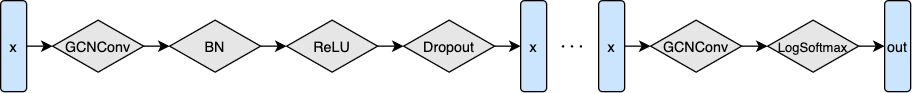

In [ ]:
import torch.nn as nn

class GCN(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim, num_layers, dropout, return_embed=False):
        super(GCN, self).__init__()
        
        self.num_layers = num_layers

        conv_list = []
        conv_list.append(GCNConv(in_channels=input_dim, out_channels=hidden_dim))
        for _ in range(num_layers -2):
            conv_list.append(GCNConv(in_channels=hidden_dim, out_channels=hidden_dim))
        conv_list.append(GCNConv(in_channels=hidden_dim, out_channels=output_dim))
        self.convs = nn.ModuleList(conv_list)

        self.bns = nn.ModuleList([nn.BatchNorm1d(num_features=hidden_dim) for _ in range(num_layers-1)])
        
        self.softmax = nn.LogSoftmax(dim=-1)
        self.dropout = dropout
        self.return_embeds = return_embed


    def reset_parameters(self):
        for conv in self.convs:
            conv.reset_parameters()
        for bn in self.bns:
            bn.reset_parameters()

    def forward(self, x, adj_t):
        # TODO: Implement a function that takes the feature tensor x and
        # edge_index tensor adj_t and returns the output tensor as
        # shown in the figure.
        out=None

        input = x
        for i in range(self.num_layers -1):
            conv = self.convs[i](input, adj_t)
            bn = self.bns[i](conv)
            relu = nn.functional.relu(bn)
            dropout = nn.functional.dropout(relu, p=self.dropout, training=self.training)
            input = dropout
        
        finalconv = self.convs[self.num_layers-1](input, adj_t)
       

        if self.return_embeds:
            out = finalconv
        else:
             out = self.softmax(finalconv)

        return out




In [22]:
def train(model, data, train_idx, optimizer, loss_fn):
    model.train()
    loss = 0

    optimizer.zero_grad()
    out = model(data.x, data.adj_t)
    loss = loss_fn(out[train_idx], data.y[train_idx].squeeze())
    loss.backward()
    optimizer.step()

    return loss.item()

In [18]:
# Test function here
@torch.no_grad()
def test(model, data, split_idx, evaluator, save_model_results=False):
    # TODO: Implement a function that tests the model by
    # using the given split_idx and evaluator.
    model.eval()

    # The output of model on all data
    out = None

    ############# Your code here ############
    ## (~1 line of code)
    ## Note:
    ## 1. No index slicing here
    out = model(data.x, data.adj_t)
    #########################################

    y_pred = out.argmax(dim=-1, keepdim=True)

    train_acc = evaluator.eval({
        'y_true': data.y[split_idx['train']],
        'y_pred': y_pred[split_idx['train']],
    })['acc']
    valid_acc = evaluator.eval({
        'y_true': data.y[split_idx['valid']],
        'y_pred': y_pred[split_idx['valid']],
    })['acc']
    test_acc = evaluator.eval({
        'y_true': data.y[split_idx['test']],
        'y_pred': y_pred[split_idx['test']],
    })['acc']

    if save_model_results:
      print ("Saving Model Predictions")

      data = {}
      data['y_pred'] = y_pred.view(-1).cpu().detach().numpy()

      df = pd.DataFrame(data=data)
      # Save locally as csv
      df.to_csv('ogbn-arxiv_node.csv', sep=',', index=False)


    return train_acc, valid_acc, test_acc

In [11]:
args = {
      'device': device,
      'num_layers': 3,
      'hidden_dim': 256,
      'dropout': 0.5,
      'lr': 0.01,
      'epochs': 100,
  }

In [13]:
model = GCN(data.num_features, args['hidden_dim'],
              dataset.num_classes, args['num_layers'],
              args['dropout']).to(device)
evaluator = Evaluator(name='ogbn-arxiv')

In [ ]:
import copy

model.reset_parameters()

optimizer = torch.optim.Adam(model.parameters(), lr=args['lr'])
loss_fn = F.nll_loss

best_model = None
best_valid_acc = 0

for epoch in range(1, 1 + args["epochs"]):
    loss = train(model, data, train_idx, optimizer, loss_fn)
    result = test(model, data, split_idx, evaluator)
    train_acc, valid_acc, test_acc = result
    
    if valid_acc > best_valid_acc:
        best_valid_acc = valid_acc
        best_model = copy.deepcopy(model)
    print(f'Epoch: {epoch:02d},'f'Loss: {loss:.4f}, 'f'Train: {100 * train_acc:.2f}%, 'f'Valid: {100 * valid_acc:.2f}% 'f'Test: {100 * test_acc:.2f}%')

Epoch: 01,Loss: 1.4882, Train: 53.91%, Valid: 49.38% Test: 42.14%
Epoch: 02,Loss: 1.7460, Train: 58.22%, Valid: 55.33% Test: 48.75%
Epoch: 03,Loss: 1.5524, Train: 58.07%, Valid: 57.21% Test: 51.48%
Epoch: 04,Loss: 1.6309, Train: 57.76%, Valid: 56.39% Test: 50.65%
Epoch: 05,Loss: 1.5741, Train: 56.71%, Valid: 54.57% Test: 49.05%
Epoch: 06,Loss: 1.5401, Train: 56.04%, Valid: 53.38% Test: 47.74%
Epoch: 07,Loss: 1.5278, Train: 56.66%, Valid: 53.46% Test: 47.36%
Epoch: 08,Loss: 1.5263, Train: 57.86%, Valid: 54.05% Test: 47.20%
Epoch: 09,Loss: 1.5080, Train: 58.72%, Valid: 54.89% Test: 47.74%
Epoch: 10,Loss: 1.4930, Train: 59.19%, Valid: 55.55% Test: 48.04%
Epoch: 11,Loss: 1.4880, Train: 59.57%, Valid: 56.40% Test: 48.86%
Epoch: 12,Loss: 1.4867, Train: 59.94%, Valid: 57.17% Test: 50.06%
Epoch: 13,Loss: 1.4734, Train: 60.11%, Valid: 57.82% Test: 51.16%
Epoch: 14,Loss: 1.4679, Train: 60.25%, Valid: 57.98% Test: 51.76%
Epoch: 15,Loss: 1.4639, Train: 60.32%, Valid: 57.99% Test: 52.23%
Epoch: 16,

In [24]:
best_result = test(best_model, data, split_idx, evaluator, save_model_results=True)
train_acc, valid_acc, test_acc = best_result
print(f'Best model: '
        f'Train: {100 * train_acc:.2f}%, '
        f'Valid: {100 * valid_acc:.2f}% '
        f'Test: {100 * test_acc:.2f}%')

Saving Model Predictions
Best model: Train: 66.65%, Valid: 60.89% Test: 55.00%
